# Image Datasets

Here we present and visualize the image datasets available in the framework. Those are:

- dSprites
- COIL-20

To load the datasets, you need to first do the following:

- Install the `microscope` project, i.e. run `pip install .` on the top level directory of the repository.
- For COIL-20:
    - To fetch the dataset, run the following command inside a directory of choice: `wget http://www.cs.columbia.edu/CAVE/databases/SLAM_coil-20_coil-100/coil-20/coil-20-proc.zip`

      If for some reason this does not work, you can manually get it from here: https://www.cs.columbia.edu/CAVE/software/softlib/coil-20.php. It is the pre-processed one!
  - Unzip in a preferred location.
  - In the code below, set the `COIL20_PATH` environment variable to the path of the unzipped `coild-20-proc`.

**WARNINGS:** 
- Computing the measures can be significantly accelerated by using a GPU. Nevertheless, one should be able to compute them on a CPU in reasonable time for lower dimension versions of the datasets, for example 2D.
- For the larger datasets, specifically the full 4-dimensional dSprites, one needs  ~30GB RAM available to comfortable load and process it.

In [1]:
%load_ext autoreload
%autoreload 2

In [5]:
import os
from pathlib import Path
from pprint import pprint
from dataclasses import fields

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from microscope.datasets.generic_dataset_loader import load_dataset
from microscope.datasets import custom_dsprites, coil20
from microscope.computations_grid.data_analysis.data_analysis import (
    compute_measures_multiclass,
    plot_3d_pca_projections_multiclass,
    clip_results_multiclass
)

# Repalce this with your path to "coil-20-proc".
os.environ["COIL20_PATH"] = str(Path("~/datasets/curvature-landscapes/coil-20-proc").expanduser()) 

## dSprites

The dSprites dataset was introduced by Google DeepMind: https://github.com/google-deepmind/dsprites-dataset. It consists of 3 simple shape sprites, a square, an ellipse and a heart colored white and added on a black background. Then, for given ranges, all possible combinations of different sprites, sizes, rotations and xy positions are considered. The original purpose of the dataset was to assess the disentanglement properties of unsupervised learning methods.

To better suit our purposes, we adjust a bit the dataset, specifically:

- The original dataset had only 6 size scales. This is quite restricting for our coputations of geometric measures with finite difference, especially for curvature which needs a margin of 3 along each non-cyclic dimension. For this reason, we balance the number of values per dimension so that they are all 22 (16 when restricting to the points where curvature can be computed), except for the roations the only cyclic dimension which has 16 values.
- The original dataset restricted the pixel values to 0 and 1 while we use a continuous range $[0, 1]$ which results to a smoother data manifold.
- We provide default ways to restric the dataset from 4 to 3, 2, or 1 dimensions.
  The dataset generator is quite flexible and could be used to generate different flavors of the dataset as needed.

Default dataset properties:

- Ambient space: $R^{4096}$
- Manifold dimension: $4$
- Manifold, single class: $M = I\times S^1\times I\times I$, where $I = [0, 1]$
- Manifold: $M\sqcup M\sqcup M$
- Number of data points: $511,104 = 3\cdot 22\cdot 16\cdot 22\cdot 22$

Transforms for the versions with different dimensions:

- 4 dimensions: size, rotation, y translation, x translation
- 3 dimensions: size, rotation, y translation
- 2 dimensions: size, rotation
- 1 dimensions: rotation

Customizable dataset parameters:

- Image size
- dSprites size (maximum scale)
- Number of values per transform
- Option to increase/reduce blurring to get sharper/smoother data manifolds

To cite the original dSprites:

```
@misc{dsprites17,
author = {Loic Matthey and Irina Higgins and Demis Hassabis and Alexander Lerchner},
title = {dSprites: Disentanglement testing Sprites dataset},
howpublished= {https://github.com/deepmind/dsprites-dataset/},
year = "2017",
}
```

### dSprites 2D version: size and rotation

In [ ]:
dims = 2

data, target, range_sizes, cyclic_dimensions, patch_sizes = load_dataset(
    dataset_name="custom_dsprites_balanced",
    number_of_dims=dims,
    ratio_per_dim=False,
    training_ratio=1.0,
    noise_sigma=0.0,
    save_train_idx=False,
    weight_subsampling_by_manifold_volume=False,
    return_full_datasets=True,
    return_dataset_unflat_with_metadata=True,
    full_datasets_unclipped=True
)
print(f"Data shape: {data.shape}, target shape: {target.shape}")

x-translate:  64%|███████████████████           | 14/22 [00:04<00:02,  3.00it/s]

#### dSprites 2D: Visualize some images

In [ ]:
stride = 3
stride_rot = 2
sprite_class = 2
sep_vertical = np.zeros((data.shape[-1], 1))
diff_sizes = np.hstack([np.hstack([data[sprite_class, i, 0], sep_vertical]) for i in np.arange(0, 22, stride)])
diff_rotations = np.hstack([np.hstack([data[sprite_class, 0, i], sep_vertical]) for i in np.arange(0, 16, stride_rot)])

sep_horizontal = np.zeros((1, diff_sizes.shape[-1]))
examples_image = np.vstack([
    diff_sizes, 
    sep_horizontal, 
    diff_rotations
])

plt.figure(figsize=(10, 5))
plt.imshow(examples_image, cmap="gray")
plt.show()

#### dSprites 2D: Compute measures and clip the data

Below are the descriptions of the measures. Note that every measure which starts with `normalized` has been computed on a isotropically scaled version of the space where the total manifold has volume 1. The description `total` implies that the corresponding geometric measure has been integrated over the manifold with the volume element.

- `total_volumes`: The total volume of the manifold of each class
- `normalized_total_volumes`: The total volume of the manifold of each class after scaling.
- `normalized_total_curvatures`: The total scalar curvature.
- `normalized_total_curvatures_positive`: The total positive scalar curvature. The negative values are set to 0 and the rest is integrated.
- `normalized_total_curvatures_negative`: The total negative scalar curvature. The positive values are set to 0 and the rest is integrated.
- `normalized_min_reaches`: The minimum of the local reach on the manifolds (i.e. exactly the reach).
- `normalized_total_reaches`: The integral of the local values of the reach.
- `normalized_total_distances`: The itegral of the pointwise distances between the manifolds. The points are mapped cross-classes by the values of their transforms.
- `normalized_average_distances`: The average of pointwise distances between the manifolds. The distances are simply added over all points (transform combiations) and divided by their number.

In [ ]:
# Flatten the transform and image dimensions.
features_on_grid = data.reshape((*data.shape[:-2], np.prod(data.shape[-2:])))

# Compute the geometric measures.
measures = compute_measures_multiclass(
    data=features_on_grid,
    class_names=list(custom_dsprites.LABEL_MAPPING.values()),
    range_sizes=range_sizes,
    cyclic_dimensions=cyclic_dimensions,
    patch_sizes=patch_sizes,
    reach_subsample=2,
    normalize_for_volume=True
)

# Clip the measures and flattened data to account for a margin lost during finite differences computations.
measures_clipped = clip_results_multiclass(measures)
features_on_grid_trimmed = features_on_grid[measures_clipped.trim_slices_data]

In [ ]:
pd.DataFrame({
    field.name:
    {
        k: round(v, 2) for k, v in getattr(measures_clipped.measure_aggregates, field.name).items()
    } 
    for field in fields(measures_clipped.measure_aggregates)
}).fillna("")

#### dSprites 2D: 3D plot of the PCA projection of the dataset

In [ ]:
# If available, enable interactive matplotlib to better examine the 3D plots.
# %matplotlib qt
%matplotlib inline

In [ ]:
plot_3d_pca_projections_multiclass(
    features_on_grid_trimmed,
    measures_clipped,
    alpha=1.0,
    show=True,
    n_samples_for_plots=5_000
)

### dSprites 4D version: size, rotation, y translation, x translation

In [142]:
dims = 4

data, target, range_sizes, cyclic_dimensions, patch_sizes = load_dataset(
    dataset_name="custom_dsprites_balanced",
    number_of_dims=dims,
    ratio_per_dim=False,
    training_ratio=1.0,
    noise_sigma=0.0,
    save_train_idx=False,
    weight_subsampling_by_manifold_volume=False,
    return_full_datasets=True,
    return_dataset_unflat_with_metadata=True,
    full_datasets_unclipped=True
)
print(f"Data shape: {data.shape}, target shape: {target.shape}")

x-translate: 100%|██████████████████████████████| 22/22 [00:06<00:00,  3.15it/s]


Data shape: (3, 22, 16, 22, 22, 64, 64), target shape: (3, 22, 16, 22, 22)


#### dSprites 4D: Visualize some images

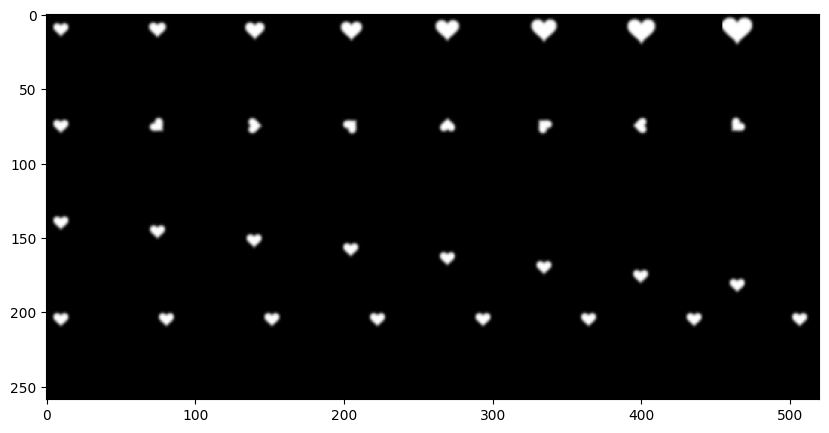

In [143]:
stride = 3
stride_rot = 2
sprite_class = 2
sep_vertical = np.zeros((data.shape[-1], 1))
diff_sizes = np.hstack([np.hstack([data[sprite_class, i, 0, 0, 0], sep_vertical]) for i in np.arange(0, 22, stride)])
diff_rotations = np.hstack([np.hstack([data[sprite_class, 0, i, 0, 0], sep_vertical]) for i in np.arange(0, 16, stride_rot)])
diff_y_trans = np.hstack([np.hstack([data[sprite_class, 0, 0, i, 0], sep_vertical]) for i in np.arange(0, 22, stride)])
diff_x_trans = np.hstack([np.hstack([data[sprite_class, 0, 0, 0, i], sep_vertical]) for i in np.arange(0, 22, stride)])

sep_horizontal = np.zeros((1, diff_sizes.shape[-1]))
examples_image = np.vstack([
    diff_sizes, 
    sep_horizontal, 
    diff_rotations,
    sep_horizontal,
    diff_y_trans,
    sep_horizontal,
    diff_x_trans
])

plt.figure(figsize=(10, 5))
plt.imshow(examples_image, cmap="gray")
plt.show()

#### dSprites 4D: Compute measures and clip the data

Below are the descriptions of the measures. Note that every measure which starts with `normalized` has been computed on a isotropically scaled version of the space where the total manifold has volume 1. The description `total` implies that the corresponding geometric measure has been integrated over the manifold with the volume element.

- `total_volumes`: The total volume of the manifold of each class
- `normalized_total_volumes`: The total volume of the manifold of each class after scaling.
- `normalized_total_curvatures`: The total scalar curvature.
- `normalized_total_curvatures_positive`: The total positive scalar curvature. The negative values are set to 0 and the rest is integrated.
- `normalized_total_curvatures_negative`: The total negative scalar curvature. The positive values are set to 0 and the rest is integrated.
- `normalized_min_reaches`: The minimum of the local reach on the manifolds (i.e. exactly the reach).
- `normalized_total_reaches`: The integral of the local values of the reach.
- `normalized_total_distances`: The itegral of the pointwise distances between the manifolds. The points are mapped cross-classes by the values of their transforms.
- `normalized_average_distances`: The average of pointwise distances between the manifolds. The distances are simply added over all points (transform combiations) and divided by their number.

In [144]:
%%time
# WARNING: This is the largest dataset, so this will take around 5 minutes, using a GPU.

# Flatten the transform and image dimensions.
features_on_grid = data.reshape((*data.shape[:-2], np.prod(data.shape[-2:])))

# Compute the geometric measures.
measures = compute_measures_multiclass(
    data=features_on_grid,
    class_names=list(custom_dsprites.LABEL_MAPPING.values()),
    range_sizes=range_sizes,
    cyclic_dimensions=cyclic_dimensions,
    patch_sizes=patch_sizes,
    reach_subsample=2,
    normalize_for_volume=True
)

# Clip the measures and flattened data to account for a margin lost during finite differences computations.
measures_clipped = clip_results_multiclass(measures)
features_on_grid_trimmed = features_on_grid[measures_clipped.trim_slices_data]

Computing measures for square.


100%|███████████████████████████████████████| 4000/4000 [00:57<00:00, 69.50it/s]


Computing measures for ellipse.


100%|███████████████████████████████████████| 4000/4000 [00:57<00:00, 69.34it/s]


Computing measures for heart.


100%|███████████████████████████████████████| 4000/4000 [00:58<00:00, 68.96it/s]


CPU times: user 4min 15s, sys: 1min 22s, total: 5min 38s
Wall time: 4min 55s


In [145]:
pd.DataFrame({
    field.name:
    {
        k: round(v, 2) for k, v in getattr(measures_clipped.measure_aggregates, field.name).items()
    } 
    for field in fields(measures_clipped.measure_aggregates)
}).fillna("")

,total_volumes,normalized_total_volumes,normalized_total_curvatures,normalized_total_curvatures_positive,normalized_total_curvatures_negative,normalized_min_reaches,normalized_total_reaches,normalized_total_distances,normalized_average_distances
square,11730869.55,0.53,-10.66,226.09,-247.4,0.01,0.01,,
ellipse,3426791.15,0.16,-17.46,379.42,-414.33,0.0,0.0,,
heart,5522776.55,0.25,-15.17,323.14,-353.47,0.02,0.01,,
"(square, ellipse)",,,,,,,,0.05,0.01
"(square, heart)",,,,,,,,0.05,0.01
"(ellipse, heart)",,,,,,,,0.02,0.0


#### dSprites 4D: 3D plot of the PCA projection of the dataset

In [146]:
# If available, enable interactive matplotlib to better examine the 3D plots.
# %matplotlib qt
%matplotlib inline

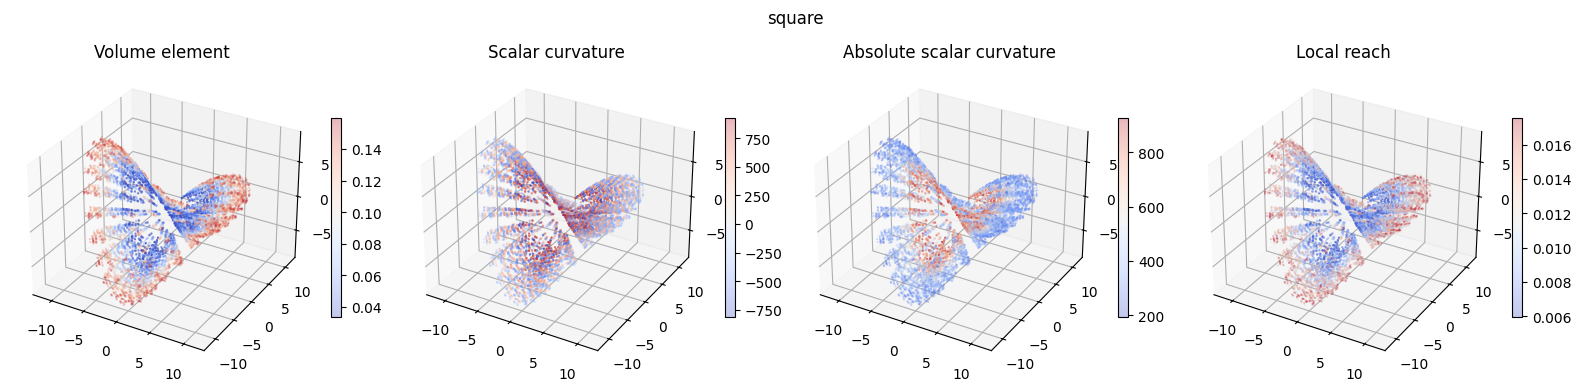

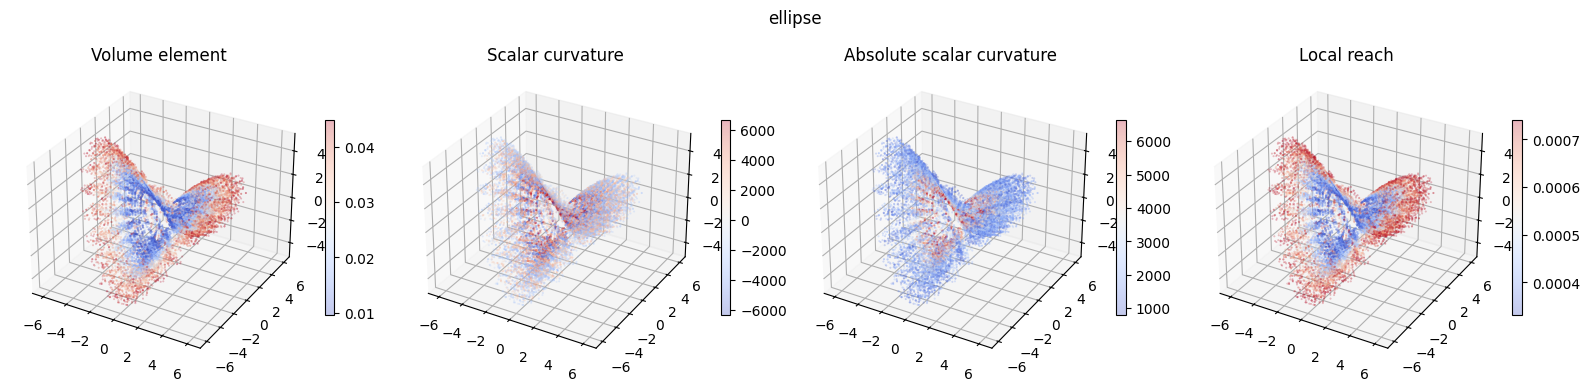

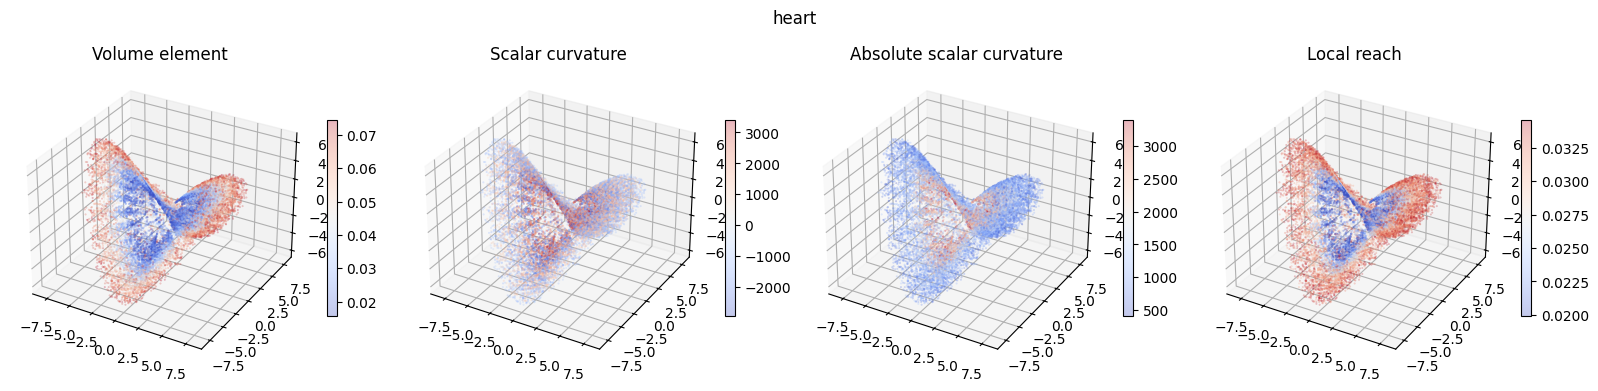

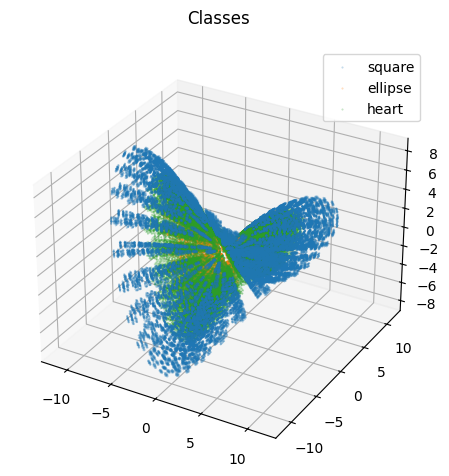

In [147]:
plot_3d_pca_projections_multiclass(
    features_on_grid_trimmed,
    measures_clipped,
    alpha=0.3,
    show=True,
    n_samples_for_plots=20_000
)

## COIL-20

The COIL-20 dataset was introduced by a group of the Columbia University: https://www.cs.columbia.edu/CAVE/software/softlib/coil-20.php. It consists of 20 objects photographed from different horizontal angles on a black background.

To better suit our purposes, we adjust a bit the dataset, specifically:

- The original dataset used 72 angles per object. This is too dense, for our purposes we subsample to 18 angles.
- We augment the dataset with object resizing and yz rotations, thus adding two more dimensions to it.
- We downsize the images from $128\times 128$ to $64\times 64$.
  The dataset generator is quite flexible and could be used to generate different flavors of the dataset as needed.

Default dataset properties:

- Ambient space: $R^{4096}$
- Manifold dimension: $3$
- Manifold, single class: $M = S^1\times I\times S^1$, where $I = [0, 1]$
- Manifold: $\bigsqcup\limits_{i\in \{1, \ldots, 20\}} M$
- Number of data points: $126,720 = 20\cdot 18\cdot 22\cdot 16$

Transforms for the versions with different dimensions:

- 3 dimensions: xy rotation, size, yz rotation
- 2 dimensions: xy rotation, yz rotation
- 1 dimensions: xy rotation

Customizable dataset parameters:

- Image size
- Object size (maximum scale)
- Number of values per transform

To cite the original COIL-20 dataset:

```
@article{nene1996columbia,
  title={Columbia object image library (coil-20)},
  author={Nene, Sameer A and Nayar, Shree K and Murase, Hiroshi and others},
  year={1996},
  publisher={Citeseer}
}
```

### COIL-20 3D version: xy-rotation, yz-rotation, size

In [170]:
dims = 3

data, target, range_sizes, cyclic_dimensions, patch_sizes = load_dataset(
    dataset_name="extended_coil20",
    number_of_dims=dims,
    ratio_per_dim=False,
    training_ratio=1.0,
    noise_sigma=0.0,
    save_train_idx=False,
    weight_subsampling_by_manifold_volume=False,
    return_full_datasets=True,
    return_dataset_unflat_with_metadata=True,
    full_datasets_unclipped=True
)
print(f"Data shape: {data.shape}, target shape: {target.shape}")

# We restrict the dataset to the first 3 object classes to save some time on the measures computation and also have more interpretable plots.
# This can be commented out and run for all 20 objects.
data = data[:3]
target = target[:3]

print(f"Restricted to 3 objects data shape: {data.shape}, target shape: {target.shape}")

resize: 100%|███████████████████████████████████| 22/22 [00:06<00:00,  3.58it/s]


Data shape: (20, 18, 22, 16, 64, 64), target shape: (20, 18, 22, 16)
Restricted to 3 objects data shape: (3, 18, 22, 16, 64, 64), target shape: (3, 18, 22, 16)


#### COIL-20 3D: Visualize some images

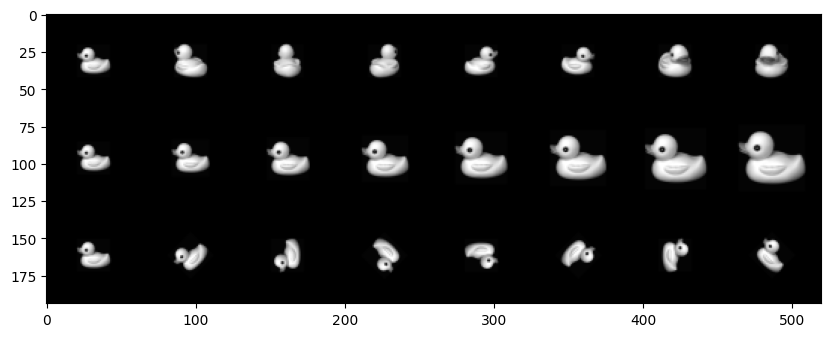

In [172]:
object_class = 0
sep_vertical = np.zeros((data.shape[-1], 1))
diff_xy_rotations = np.hstack([np.hstack([data[object_class, i, 0, 0], sep_vertical]) for i in np.arange(0, 16, 2)])
diff_sizes = np.hstack([np.hstack([data[object_class, 0, i, 0], sep_vertical]) for i in np.arange(0, 22, 3)])
diff_yz_rotations = np.hstack([np.hstack([data[object_class, 0, 0, i], sep_vertical]) for i in np.arange(0, 16, 2)])

sep_horizontal = np.zeros((1, diff_sizes.shape[-1]))
examples_image = np.vstack([
    diff_xy_rotations, 
    sep_horizontal, 
    diff_sizes,
    sep_horizontal,
    diff_yz_rotations
])

plt.figure(figsize=(10, 5))
plt.imshow(examples_image, cmap="gray")
plt.show()

#### COIL-20 3D: Compute measures and clip the data

Below are the descriptions of the measures. Note that every measure which starts with `normalized` has been computed on a isotropically scaled version of the space where the total manifold has volume 1. The description `total` implies that the corresponding geometric measure has been integrated over the manifold with the volume element.

- `total_volumes`: The total volume of the manifold of each class
- `normalized_total_volumes`: The total volume of the manifold of each class after scaling.
- `normalized_total_curvatures`: The total scalar curvature.
- `normalized_total_curvatures_positive`: The total positive scalar curvature. The negative values are set to 0 and the rest is integrated.
- `normalized_total_curvatures_negative`: The total negative scalar curvature. The positive values are set to 0 and the rest is integrated.
- `normalized_min_reaches`: The minimum of the local reach on the manifolds (i.e. exactly the reach).
- `normalized_total_reaches`: The integral of the local values of the reach.
- `normalized_total_distances`: The itegral of the pointwise distances between the manifolds. The points are mapped cross-classes by the values of their transforms.
- `normalized_average_distances`: The average of pointwise distances between the manifolds. The distances are simply added over all points (transform combiations) and divided by their number.

In [174]:
%%time
# Flatten the transform and image dimensions.
features_on_grid = data.reshape((*data.shape[:-2], np.prod(data.shape[-2:])))

# Compute the geometric measures.
measures = compute_measures_multiclass(
    data=features_on_grid,
    class_names=list(coil20.LABEL_MAPPING.values())[:3],  # Remove the slicing, in case you run this for all objects.
    range_sizes=range_sizes,
    cyclic_dimensions=cyclic_dimensions,
    patch_sizes=patch_sizes,
    reach_subsample=2,
    normalize_for_volume=True
)

# Clip the measures and flattened data to account for a margin lost during finite differences computations.
measures_clipped = clip_results_multiclass(measures)
features_on_grid_trimmed = features_on_grid[measures_clipped.trim_slices_data]

Computing measures for duck.


100%|████████████████████████████████████████| 360/360 [00:00<00:00, 516.40it/s]


Computing measures for wood_triangle.


100%|████████████████████████████████████████| 360/360 [00:00<00:00, 513.92it/s]


Computing measures for car0.


100%|████████████████████████████████████████| 360/360 [00:00<00:00, 528.33it/s]


CPU times: user 6.09 s, sys: 1.86 s, total: 7.95 s
Wall time: 6.67 s


In [175]:
pd.DataFrame({
    field.name:
    {
        k: round(v, 2) for k, v in getattr(measures_clipped.measure_aggregates, field.name).items()
    } 
    for field in fields(measures_clipped.measure_aggregates)
}).fillna("")

,total_volumes,normalized_total_volumes,normalized_total_curvatures,normalized_total_curvatures_positive,normalized_total_curvatures_negative,normalized_min_reaches,normalized_total_reaches,normalized_total_distances,normalized_average_distances
duck,308619.62,0.3,-0.34,65.05,-53.3,0.02,0.01,,
wood_triangle,441568.14,0.43,1.73,72.54,-91.92,0.02,0.01,,
car0,242281.19,0.24,0.55,32.07,-36.63,0.01,0.0,,
"(duck, wood_triangle)",,,,,,,,0.04,0.0
"(duck, car0)",,,,,,,,0.04,0.0
"(wood_triangle, car0)",,,,,,,,0.05,0.0


#### COIL-20 3D: 3D plot of the PCA projection of the dataset

In [182]:
# If available, enable interactive matplotlib to better examine the 3D plots.
# %matplotlib qt
%matplotlib inline

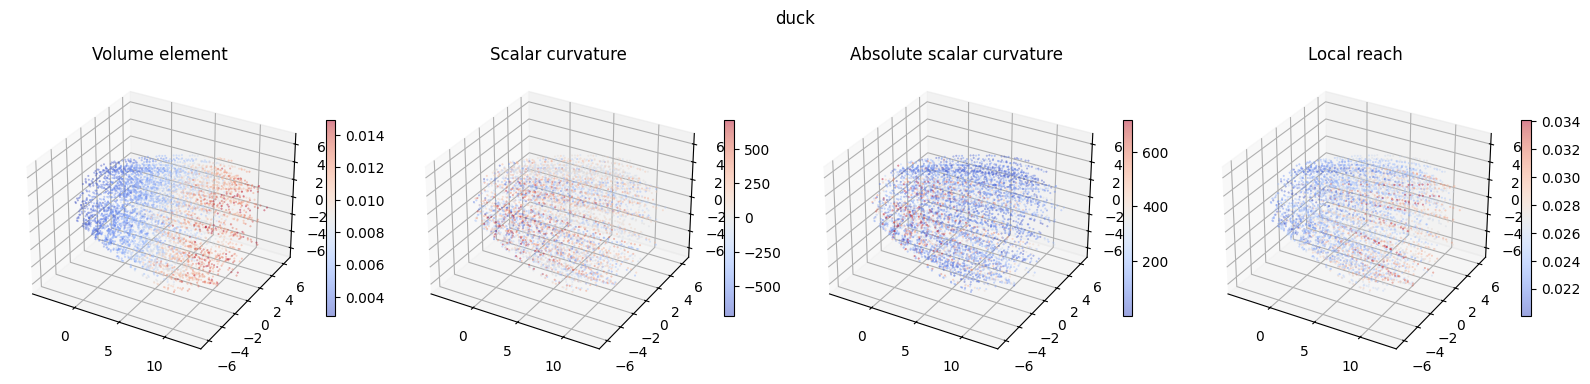

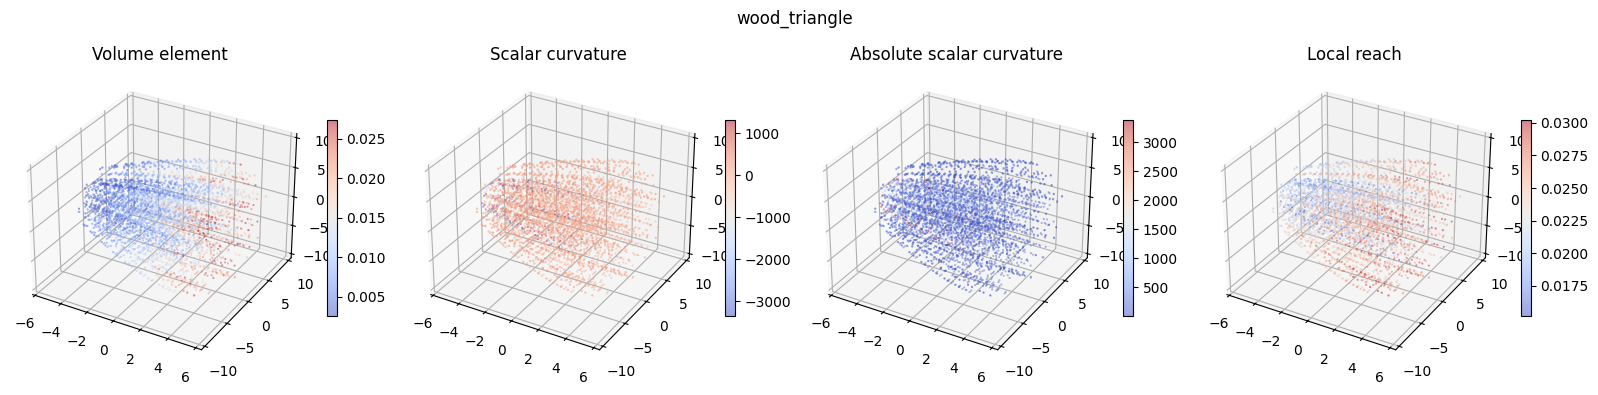

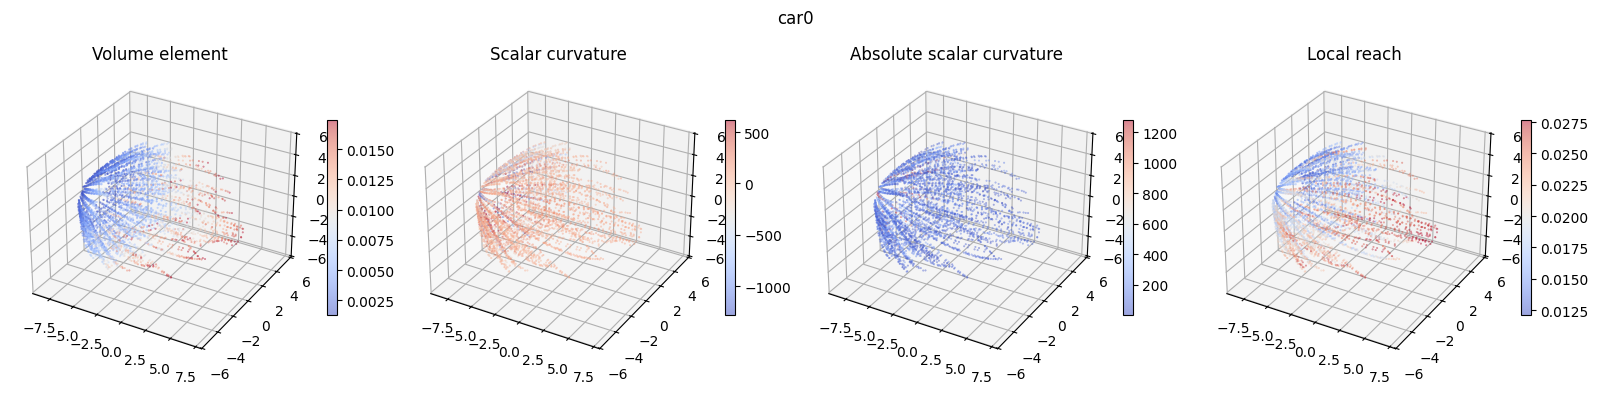

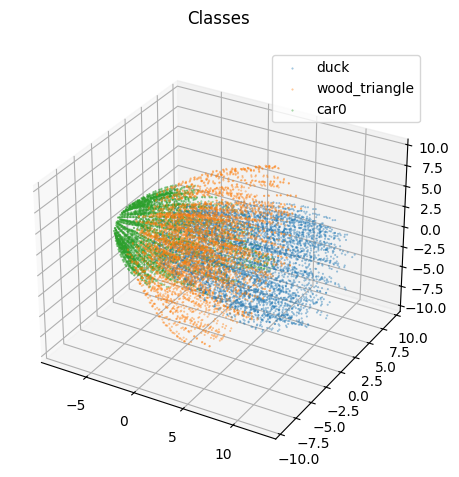

In [183]:
plot_3d_pca_projections_multiclass(
    features_on_grid_trimmed,
    measures_clipped,
    alpha=0.5,
    show=True,
    n_samples_for_plots=20_000
)